# T1 Dataset Analysis
Analysis of the new T1 ADNI dataset: Spatially Normalized, Masked, and N3 corrected.

In [1]:
import os
import csv
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from collections import Counter
from concurrent.futures import ProcessPoolExecutor
import glob

BASE_DIR = "/home/fnp23/python_projects/neuro_interp"
T1_DIR = os.path.join(BASE_DIR, "data", "T1", "ADNI")
CSV_DIR = os.path.join(BASE_DIR, "data", "project_1_3_data", "IID")
TRAIN_CSV = os.path.join(CSV_DIR, "ADNI_binary_training.csv")
TEST_CSV = os.path.join(CSV_DIR, "ADNI_binary_testing.csv")

## 1. Inventory: How many patients, how many scans per patient?

In [15]:
# Build a map of all NIfTI files
scan_inventory = {}  # pid -> list of nifti paths

for folder_name in sorted(os.listdir(T1_DIR)):
    folder_path = os.path.join(T1_DIR, folder_name)
    if not os.path.isdir(folder_path):
        continue
    parts = folder_name.split("_S_")
    if len(parts) != 2:
        continue
    pid = int(parts[1])
    
    # Find all .nii/.nii.gz files recursively
    niftis = glob.glob(os.path.join(folder_path, "**", "*.nii"), recursive=True)
    niftis += glob.glob(os.path.join(folder_path, "**", "*.nii.gz"), recursive=True)
    
    if niftis:
        scan_inventory[pid] = sorted(niftis)

print(f"Total patients with T1 scans: {len(scan_inventory)}")
scans_per_patient = [len(v) for v in scan_inventory.values()]
print(f"Scans per patient: min={min(scans_per_patient)}, max={max(scans_per_patient)}, "
      f"mean={np.mean(scans_per_patient):.1f}, median={np.median(scans_per_patient):.0f}")
print(f"Distribution: {Counter(scans_per_patient).most_common(10)}")
print(f"Total NIfTI files: {sum(scans_per_patient)}")

Total patients with T1 scans: 282
Scans per patient: min=1, max=1, mean=1.0, median=1
Distribution: [(1, 282)]
Total NIfTI files: 282


## 2. Match with labels

In [3]:
def load_csv(path):
    data = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            data[int(row["Patient_ID"])] = float(row["Label"])
    return data

train_labels = load_csv(TRAIN_CSV)
test_labels = load_csv(TEST_CSV)
all_labels = {**train_labels, **test_labels}

t1_pids = set(scan_inventory.keys())
train_pids = t1_pids & set(train_labels)
test_pids = t1_pids & set(test_labels)
unlabeled_pids = t1_pids - set(all_labels)

print(f"── Patient Matching ──")
print(f"T1 patients: {len(t1_pids)}")
print(f"Matched to training CSV: {len(train_pids)}")
print(f"Matched to testing CSV:  {len(test_pids)}")
print(f"No label found: {len(unlabeled_pids)}")
if unlabeled_pids:
    print(f"  Unlabeled PIDs (first 10): {sorted(unlabeled_pids)[:10]}")

print(f"\n── Label Distribution (matched) ──")
for name, pids, labels in [("Train", train_pids, train_labels), ("Test", test_pids, test_labels)]:
    ad = sum(1 for p in pids if labels[p] == 1.0)
    cn = sum(1 for p in pids if labels[p] == 0.0)
    total = len(pids)
    print(f"  {name}: {total} total — AD: {ad} ({100*ad/total:.1f}%), CN: {cn} ({100*cn/total:.1f}%)")

── Patient Matching ──
T1 patients: 282
Matched to training CSV: 106
Matched to testing CSV:  108
No label found: 68
  Unlabeled PIDs (first 10): [2047, 2052, 2071, 2110, 2111, 2125, 2142, 2150, 2213, 2219]

── Label Distribution (matched) ──
  Train: 106 total — AD: 55 (51.9%), CN: 51 (48.1%)
  Test: 108 total — AD: 66 (61.1%), CN: 42 (38.9%)


## 3. NIfTI Header Analysis
Check spatial metadata: affine, orientation, voxel sizes, sform/qform codes.

In [4]:
# Inspect headers of first 10 patients
sample_pids = sorted(scan_inventory.keys())[:10]

for pid in sample_pids:
    path = scan_inventory[pid][0]  # first scan
    img = nib.load(path)
    ornt = nib.orientations.io_orientation(img.affine)
    axcodes = nib.orientations.ornt2axcodes(ornt)
    
    print(f"PID {pid}:")
    print(f"  Shape: {img.shape}")
    print(f"  Voxel sizes: {np.round(img.header.get_zooms(), 3)}")
    print(f"  Orientation: {axcodes}")
    print(f"  sform_code: {img.header['sform_code']}, qform_code: {img.header['qform_code']}")
    print(f"  Affine diagonal: {np.round(np.diag(img.affine), 3)}")
    print()

PID 123:
  Shape: (110, 110, 110)
  Voxel sizes: [2. 2. 2.]
  Orientation: ('L', 'A', 'S')
  sform_code: 2, qform_code: 2
  Affine diagonal: [-2.  2.  2.  1.]

PID 610:
  Shape: (110, 110, 110)
  Voxel sizes: [2. 2. 2.]
  Orientation: ('L', 'A', 'S')
  sform_code: 2, qform_code: 2
  Affine diagonal: [-2.  2.  2.  1.]

PID 671:
  Shape: (110, 110, 110)
  Voxel sizes: [2. 2. 2.]
  Orientation: ('L', 'A', 'S')
  sform_code: 2, qform_code: 2
  Affine diagonal: [-2.  2.  2.  1.]

PID 778:
  Shape: (110, 110, 110)
  Voxel sizes: [2. 2. 2.]
  Orientation: ('L', 'A', 'S')
  sform_code: 2, qform_code: 2
  Affine diagonal: [-2.  2.  2.  1.]

PID 908:
  Shape: (110, 110, 110)
  Voxel sizes: [2. 2. 2.]
  Orientation: ('L', 'A', 'S')
  sform_code: 2, qform_code: 2
  Affine diagonal: [-2.  2.  2.  1.]

PID 934:
  Shape: (110, 110, 110)
  Voxel sizes: [2. 2. 2.]
  Orientation: ('L', 'A', 'S')
  sform_code: 2, qform_code: 2
  Affine diagonal: [-2.  2.  2.  1.]

PID 1074:
  Shape: (110, 110, 110)
  Vox

## 4. Full scan analysis (shapes, voxels, intensities)

In [5]:
def analyze_scan(path):
    """Analyze a single NIfTI scan."""
    try:
        img = nib.load(path)
        data = img.get_fdata(dtype=np.float32)
        ornt = nib.orientations.io_orientation(img.affine)
        axcodes = tuple(nib.orientations.ornt2axcodes(ornt))
        nz = data[data > 0]
        return {
            "shape": img.shape,
            "voxel_sizes": tuple(np.round(img.header.get_zooms(), 4)),
            "orientation": axcodes,
            "sform_code": int(img.header["sform_code"]),
            "dtype": str(img.header.get_data_dtype()),
            "min": float(data.min()),
            "max": float(data.max()),
            "mean": float(data.mean()),
            "std": float(data.std()),
            "nonzero_frac": float(len(nz) / data.size),
            "nonzero_mean": float(nz.mean()) if len(nz) > 0 else 0,
            "nonzero_std": float(nz.std()) if len(nz) > 0 else 0,
            "p1": float(np.percentile(data, 1)),
            "p99": float(np.percentile(data, 99)),
            "has_nan": bool(np.any(np.isnan(data))),
            "has_inf": bool(np.any(np.isinf(data))),
        }
    except Exception as e:
        return {"error": str(e)}

# Analyze first scan per patient (use most recent if multiple)
# Use the LAST scan per patient (most recent timepoint)
paths_to_analyze = []
pid_order = []
for pid in sorted(scan_inventory.keys()):
    paths_to_analyze.append(scan_inventory[pid][-1])  # last (most recent) scan
    pid_order.append(pid)

print(f"Analyzing {len(paths_to_analyze)} scans...")
results = []
for i, path in enumerate(paths_to_analyze):
    results.append(analyze_scan(path))
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(paths_to_analyze)}")

# Filter out errors
errors = [(pid_order[i], r["error"]) for i, r in enumerate(results) if "error" in r]
good = [r for r in results if "error" not in r]
print(f"\nSuccessfully analyzed: {len(good)}")
if errors:
    print(f"Errors: {len(errors)}")
    for pid, err in errors[:5]:
        print(f"  PID {pid}: {err}")

Analyzing 282 scans...
  50/282
  100/282
  150/282
  200/282
  250/282

Successfully analyzed: 282


In [6]:
# Summarize
shapes = Counter(r["shape"] for r in good)
voxel_sizes = Counter(r["voxel_sizes"] for r in good)
orientations = Counter(r["orientation"] for r in good)
sform_codes = Counter(r["sform_code"] for r in good)
dtypes = Counter(r["dtype"] for r in good)

print("── Shapes ──")
for s, c in shapes.most_common(10):
    print(f"  {s}: {c}")

print(f"\n── Voxel Sizes ──")
for v, c in voxel_sizes.most_common(10):
    print(f"  {v}: {c}")

print(f"\n── Orientations ──")
for o, c in orientations.most_common(10):
    print(f"  {o}: {c}")

print(f"\n── sform codes ── (4=MNI, 2=aligned, 1=scanner)")
for s, c in sform_codes.most_common():
    print(f"  {s}: {c}")

print(f"\n── Data Types ──")
for d, c in dtypes.most_common():
    print(f"  {d}: {c}")

print(f"\n── Intensity Statistics ──")
means = [r["nonzero_mean"] for r in good]
stds = [r["nonzero_std"] for r in good]
p99s = [r["p99"] for r in good]
nz_fracs = [r["nonzero_frac"] for r in good]
print(f"  Nonzero fraction: {np.mean(nz_fracs):.4f} ± {np.std(nz_fracs):.4f}")
print(f"  Mean of nonzero means: {np.mean(means):.2f} ± {np.std(means):.2f}")
print(f"  Mean of nonzero stds: {np.mean(stds):.2f} ± {np.std(stds):.2f}")
print(f"  99th percentile: {np.mean(p99s):.2f} ± {np.std(p99s):.2f}")
print(f"  Any NaN: {sum(1 for r in good if r['has_nan'])}")
print(f"  Any Inf: {sum(1 for r in good if r['has_inf'])}")

── Shapes ──
  (110, 110, 110): 282

── Voxel Sizes ──
  (2.0, 2.0, 2.0): 282

── Orientations ──
  ('L', 'A', 'S'): 282

── sform codes ── (4=MNI, 2=aligned, 1=scanner)
  2: 282

── Data Types ──
  >f4: 282

── Intensity Statistics ──
  Nonzero fraction: 0.1507 ± 0.0149
  Mean of nonzero means: 1374.87 ± 674.84
  Mean of nonzero stds: 713.16 ± 336.87
  99th percentile: 2344.41 ± 1121.81
  Any NaN: 0
  Any Inf: 0


## 5. Visual Inspection: Population Mean + Random Samples

In [ ]:
# Check if all shapes are the same — if so, compute population mean
if len(shapes) == 1:
    target_shape = list(shapes.keys())[0]
    print(f"All scans have shape {target_shape} — computing population mean")
else:
    # Use the most common shape
    target_shape = shapes.most_common(1)[0][0]
    print(f"Most common shape: {target_shape} ({shapes.most_common(1)[0][1]} scans)")
    print(f"Will compute mean only for scans with this shape")

sum_vol = np.zeros(target_shape, dtype=np.float64)
n = 0
for pid in sorted(scan_inventory.keys()):
    path = scan_inventory[pid][-1]
    img = nib.load(path)
    if img.shape != target_shape:
        continue
    data = img.get_fdata(dtype=np.float32)
    # Z-score per volume for comparable averaging
    nz = data > 0
    if nz.any():
        mu, sigma = data[nz].mean(), data[nz].std()
        data = np.where(nz, (data - mu) / (sigma + 1e-8), 0)
    sum_vol += data
    n += 1

mean_vol = (sum_vol / n).astype(np.float32)
print(f"Population mean computed from {n} scans")

All scans have shape (110, 110, 110) — computing population mean
Population mean computed from 282 scans


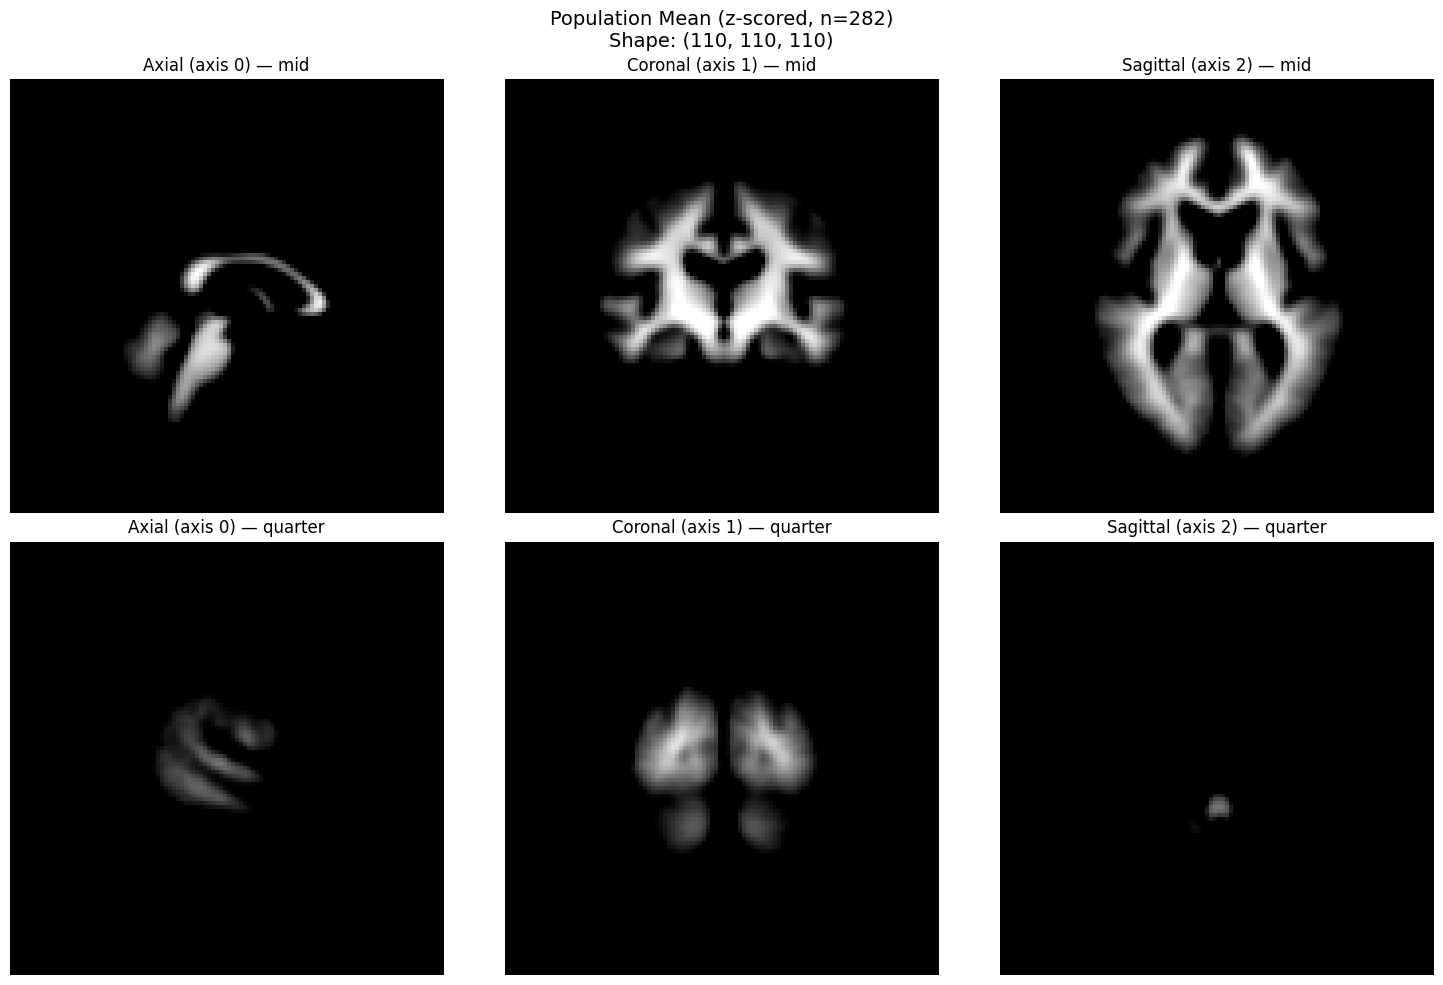

In [11]:
# Plot population mean — all 3 axes at mid and quarter positions
vmax = np.percentile(mean_vol[mean_vol > 0], 99) if np.any(mean_vol > 0) else 1.0
s = mean_vol.shape

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Population Mean (z-scored, n={n})\nShape: {target_shape}', fontsize=14)

mid = [s[0]//2, s[1]//2, s[2]//2]
quarter = [s[0]//4, s[1]//4, s[2]//4]
titles = ['Axial (axis 0)', 'Coronal (axis 1)', 'Sagittal (axis 2)']

# Mid slices
axes[0,0].imshow(mean_vol[mid[0],:,:].T, cmap='gray', origin='lower', vmin=0, vmax=vmax)
axes[0,1].imshow(mean_vol[:,mid[1],:].T, cmap='gray', origin='lower', vmin=0, vmax=vmax)
axes[0,2].imshow(mean_vol[:,:,mid[2]].T, cmap='gray', origin='lower', vmin=0, vmax=vmax)

# Quarter slices
axes[1,0].imshow(mean_vol[quarter[0],:,:].T, cmap='gray', origin='lower', vmin=0, vmax=vmax)
axes[1,1].imshow(mean_vol[:,quarter[1],:].T, cmap='gray', origin='lower', vmin=0, vmax=vmax)
axes[1,2].imshow(mean_vol[:,:,quarter[2]].T, cmap='gray', origin='lower', vmin=0, vmax=vmax)

for j, title in enumerate(titles):
    axes[0,j].set_title(f'{title} — mid')
    axes[1,j].set_title(f'{title} — quarter')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

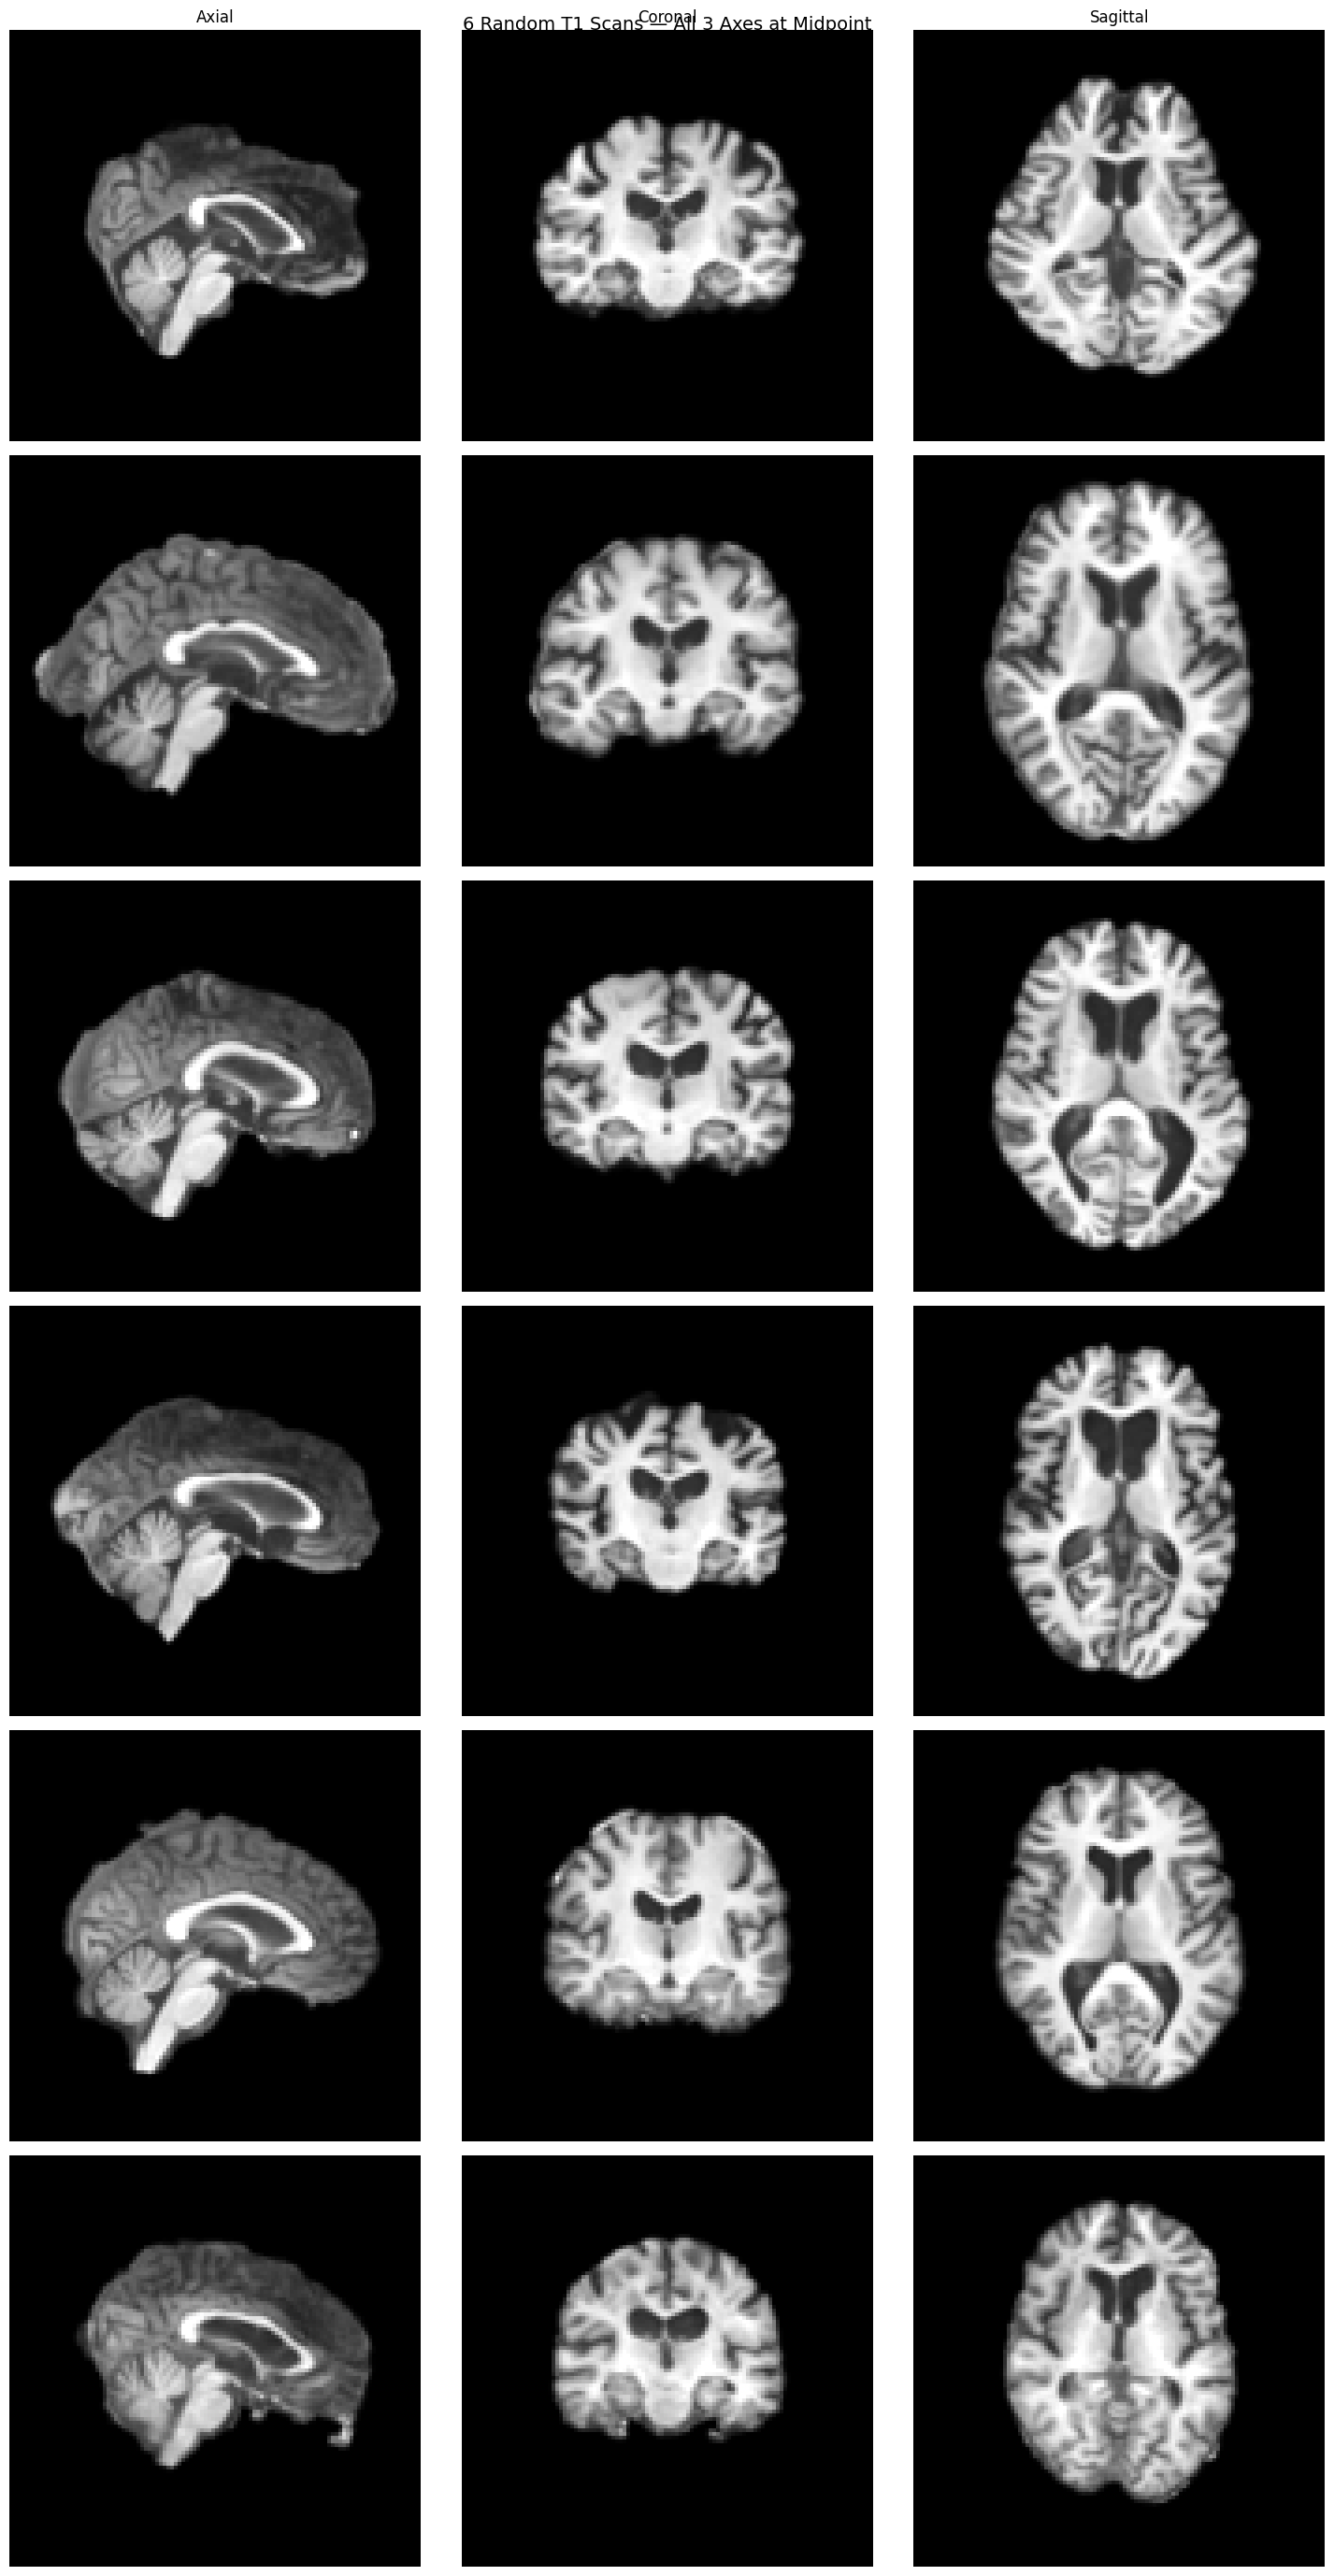

In [12]:
# Random individual samples — 6 patients, 3 axes each
import random
random.seed(42)
sample_pids = random.sample(sorted(scan_inventory.keys()), min(6, len(scan_inventory)))

fig, axes = plt.subplots(6, 3, figsize=(15, 28))
fig.suptitle('6 Random T1 Scans — All 3 Axes at Midpoint', fontsize=14)

for i, pid in enumerate(sample_pids):
    path = scan_inventory[pid][-1]
    img = nib.load(path)
    data = img.get_fdata(dtype=np.float32)
    s = data.shape
    
    vmax_i = np.percentile(data[data > 0], 99) if np.any(data > 0) else 1.0
    
    axes[i,0].imshow(data[s[0]//2,:,:].T, cmap='gray', origin='lower', vmin=0, vmax=vmax_i)
    axes[i,0].set_ylabel(f'PID {pid}\n{s}', fontsize=10)
    
    axes[i,1].imshow(data[:,s[1]//2,:].T, cmap='gray', origin='lower', vmin=0, vmax=vmax_i)
    
    axes[i,2].imshow(data[:,:,s[2]//2].T, cmap='gray', origin='lower', vmin=0, vmax=vmax_i)
    
    if i == 0:
        axes[i,0].set_title('Axial')
        axes[i,1].set_title('Coronal')
        axes[i,2].set_title('Sagittal')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Multiple timepoints — which scan to use?

In [13]:
# For patients with multiple scans, show the scan dates
multi_scan_pids = {pid: paths for pid, paths in scan_inventory.items() if len(paths) > 1}
print(f"Patients with multiple scans: {len(multi_scan_pids)}")
print(f"Patients with single scan: {len(scan_inventory) - len(multi_scan_pids)}")

if multi_scan_pids:
    print(f"\nExamples (first 5):")
    for pid in sorted(multi_scan_pids.keys())[:5]:
        paths = multi_scan_pids[pid]
        print(f"  PID {pid}: {len(paths)} scans")
        for p in paths:
            # Extract date from path
            parts = p.split('/')
            for part in parts:
                if len(part) >= 10 and part[4] == '-':
                    print(f"    Date: {part[:10]}")
                    break

Patients with multiple scans: 229
Patients with single scan: 53

Examples (first 5):
  PID 123: 3 scans
    Date: 2013-03-21
    Date: 2014-02-12
    Date: 2015-03-03
  PID 778: 2 scans
    Date: 2013-09-04
    Date: 2014-09-23
  PID 934: 2 scans
    Date: 2013-10-22
    Date: 2015-10-14
  PID 2007: 4 scans
    Date: 2010-06-17
    Date: 2010-08-30
    Date: 2011-03-24
    Date: 2012-03-26
  PID 2031: 6 scans
    Date: 2010-08-11
    Date: 2010-11-10
    Date: 2011-02-08
    Date: 2011-07-19
    Date: 2012-07-23
    Date: 2013-07-22


## 7. Summary & Recommendations

In [14]:
print("=" * 60)
print("T1 DATASET SUMMARY")
print("=" * 60)
print(f"Total patients: {len(scan_inventory)}")
print(f"Matched to labels: {len(train_pids) + len(test_pids)}")
print(f"  Train: {len(train_pids)}")
print(f"  Test: {len(test_pids)}")
print(f"Preprocessing: Spatially Normalized + Masked + N3 corrected")
print(f"  → Already MNI registered")
print(f"  → Already skull-stripped")
print(f"  → Already bias-corrected (N3)")
print(f"Most common shape: {shapes.most_common(1)[0]}")
print(f"Orientations: {dict(orientations)}")
print(f"sform codes: {dict(sform_codes)}")
print(f"\nKey question: Do we use first scan, last scan, or all scans per patient?")
print(f"Patients with >1 scan: {len(multi_scan_pids)}")

T1 DATASET SUMMARY
Total patients: 282
Matched to labels: 214
  Train: 106
  Test: 108
Preprocessing: Spatially Normalized + Masked + N3 corrected
  → Already MNI registered
  → Already skull-stripped
  → Already bias-corrected (N3)
Most common shape: ((110, 110, 110), 282)
Orientations: {('L', 'A', 'S'): 282}
sform codes: {2: 282}

Key question: Do we use first scan, last scan, or all scans per patient?
Patients with >1 scan: 229
